In [10]:
!pip install -q kaggle

In [11]:
from google.colab import files
files.upload()

Saving symbols_valid_meta.csv to symbols_valid_meta.csv


{'symbols_valid_meta.csv': b'Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares\nY,A,"Agilent Technologies, Inc. Common Stock",N, ,N,100.0,N,,A,A,N\nY,AA,Alcoa Corporation Common Stock ,N, ,N,100.0,N,,AA,AA,N\nY,AAAU,Perth Mint Physical Gold ETF,P, ,Y,100.0,N,,AAAU,AAAU,N\nY,AACG,"ATA Creativity Global - American Depositary Shares, each representing two common shares",Q,G,N,100.0,N,N,,AACG,N\nY,AADR,AdvisorShares Dorsey Wright ADR ETF,P, ,Y,100.0,N,,AADR,AADR,N\nY,AAL,"American Airlines Group, Inc. - Common Stock",Q,Q,N,100.0,N,N,,AAL,N\nY,AAMC,Altisource Asset Management Corp Com,A, ,N,100.0,N,,AAMC,AAMC,N\nY,AAME,Atlantic American Corporation - Common Stock,Q,G,N,100.0,N,N,,AAME,N\nY,AAN,"Aaron\'s, Inc. Common Stock",N, ,N,100.0,N,,AAN,AAN,N\nY,AAOI,"Applied Optoelectronics, Inc. - Common Stock",Q,G,N,100.0,N,N,,AAOI,N\nY,AAON,"AAON, Inc. - Common Stock",Q,Q,N,100.0,N,N,,AAON,N\nY,AAP,

In [24]:
!rm ~/.kaggle

rm: cannot remove '/root/.kaggle': Is a directory


In [25]:
!mkdir -p ~/.kaggle

In [26]:
! cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [27]:
! chmod 600 ~/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [28]:
! kaggle datasets list

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [29]:
!pip install kagglehub
import kagglehub
path = kagglehub.dataset_download("jacksoncrow/stock-market-dataset")


100%|██████████| 522M/522M [00:05<00:00, 109MB/s] 

Extracting files...


In [30]:
import pandas as pd

dataset = pd.read_csv(f"{path}/symbols_valid_meta.csv")

dataset.head()

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
0,Y,A,"Agilent Technologies, Inc. Common Stock",N,,N,100.0,N,NaN,A,A,N
1,Y,AA,Alcoa Corporation Common Stock,N,,N,100.0,N,NaN,AA,AA,N
2,Y,AAAU,Perth Mint Physical Gold ETF,P,,Y,100.0,N,NaN,AAAU,AAAU,N
3,Y,AACG,ATA Creativity Global - American Depositary Sh...,Q,G,N,100.0,N,N,NaN,AACG,N
4,Y,AADR,AdvisorShares Dorsey Wright ADR ETF,P,,Y,100.0,N,NaN,AADR,AADR,N


In [31]:

print(f'Total symbols in file: {len(dataset)}')

Total symbols in file: 8049


In [74]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [33]:
stocks = dataset[
    (dataset['ETF'] == 'N') &
    (dataset['Nasdaq Traded'] == 'Y') &
    (dataset['Test Issue'] == 'N')
]['Symbol'].dropna().tolist()

print(f'Filtered common stocks: {len(stocks)}')
print('Sample symbols:', stocks[:10])

Filtered common stocks: 5884
Sample symbols: ['A', 'AA', 'AACG', 'AAL', 'AAMC', 'AAME', 'AAN', 'AAOI', 'AAON', 'AAP']


In [34]:
dataset.columns.tolist()

['Nasdaq Traded',
 'Symbol',
 'Security Name',
 'Listing Exchange',
 'Market Category',
 'ETF',
 'Round Lot Size',
 'Test Issue',
 'Financial Status',
 'CQS Symbol',
 'NASDAQ Symbol',
 'NextShares']

We will look at the top 5 biggest Tech Stocks. APPLE (AAPL), NVIDIA (NVDA), Microsoft (MSFT), Alphabet (GOOGL), Amazon (AMZN)

In [35]:
has_aapl = "AAPL" in dataset["Symbol"].values
print(has_aapl)


True


In [36]:
has_nvda = "NVDA" in dataset["Symbol"].values
print(has_nvda)


True


In [37]:
has_msft = "MSFT" in dataset["Symbol"].values
print(has_msft)


True


In [38]:
has_alphabet = "GOOGL" in dataset["Symbol"].values
print(has_alphabet)

True


In [39]:
has_amzn = "AMZN" in dataset["Symbol"].values
print(has_amzn)

True


In [75]:
data = pd.read_csv(f"{path}/stocks/AAPL.csv")

In [76]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [77]:
data.columns.tolist()

['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Plot the price of Apple Stock over Time

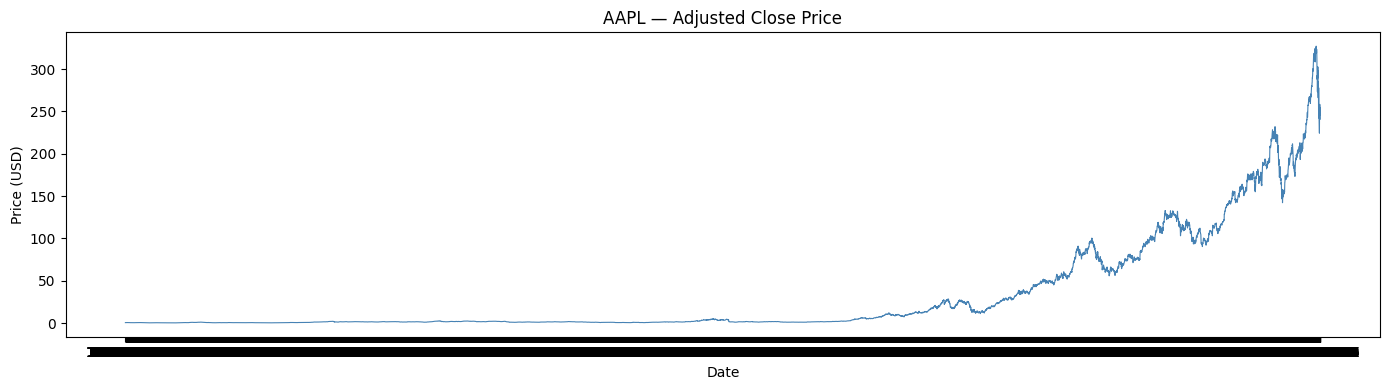

In [78]:

plt.figure(figsize=(14, 4))
plt.plot(data['Date'], data['Close'], linewidth=0.8, color='steelblue')
plt.title('AAPL — Adjusted Close Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

Volume has to get log transformed because its a huge number compared to price since it would have overweight. MinMaxScaler applied to both [0,1] because inputs work better when small numbers are close together in scale. Features and target data use this.

In [79]:
data = data[['Close', 'Volume']].copy()
data['Log_Volume'] = np.log1p(data['Volume'])
data.drop(columns=['Volume'], inplace=True)

scaler_close  = MinMaxScaler()
scaler_logvol = MinMaxScaler()

data['Close_scaled']    = scaler_close.fit_transform(data[['Close']])
data['LogVol_scaled']   = scaler_logvol.fit_transform(data[['Log_Volume']])

features = data[['Close_scaled', 'LogVol_scaled']].values
target   = data['Close_scaled'].values
print('Feature matrix:', features.shape)

Feature matrix: (9909, 2)


We take a look at 60 days previously since the data is took large to account for 80 years. It takes 60 days as input X and the next day's close as the label Y. Dataset is split 80/20 chronologically.

In [80]:

LOOKBACK = 60

X, y = [], []
for i in range(LOOKBACK, len(features)):
    X.append(features[i - LOOKBACK : i])
    y.append(target[i])

X, y = np.array(X), np.array(y)


split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (7879, 60, 2)  |  Test: (1970, 60, 2)


This is where we use the LSTM model on our data. Reads the 60 day sequence and then passes the output forward. Use a dropout of 20% to prevent overfitting. Compresses the sequence to a single summary vector. Dropout is another 20%. Dense(32) learns higher level pattern and Dense(1) outputs a number for next day.

In [81]:

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(LOOKBACK, X.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 128)        │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,593 (463.25 KB)

 Trainable params: 118,593 (463.25 KB)

 Non-trainable params: 0 (0.00 B)

This is where we use the the Convolutional Neural Network model on our data. We use Conv1D where we scan 3 days at a time, have an activation of Rectified Linear Unit. Halves the sequence length and keeps the strongest signal. A second pass with more filters that picks up high level patterns from pooled output. Flatten collapses 2d feature map into a 1d vector so dense layers can read it. Dense outputs final price

Epoch 1/5
222/222 ━━━━━━━━━━━━━━━━━━━━ 30s 111ms/step - loss: 9.0789e-05 - val_loss: 7.4056e-04
Epoch 2/5
222/222 ━━━━━━━━━━━━━━━━━━━━ 25s 114ms/step - loss: 1.4541e-05 - val_loss: 5.6401e-04
Epoch 3/5
222/222 ━━━━━━━━━━━━━━━━━━━━ 25s 112ms/step - loss: 1.0440e-05 - val_loss: 4.6191e-04
Epoch 4/5
222/222 ━━━━━━━━━━━━━━━━━━━━ 25s 112ms/step - loss: 9.1657e-06 - val_loss: 1.1507e-04
Epoch 5/5
222/222 ━━━━━━━━━━━━━━━━━━━━ 25s 111ms/step - loss: 6.9136e-06 - val_loss: 1.2474e-04


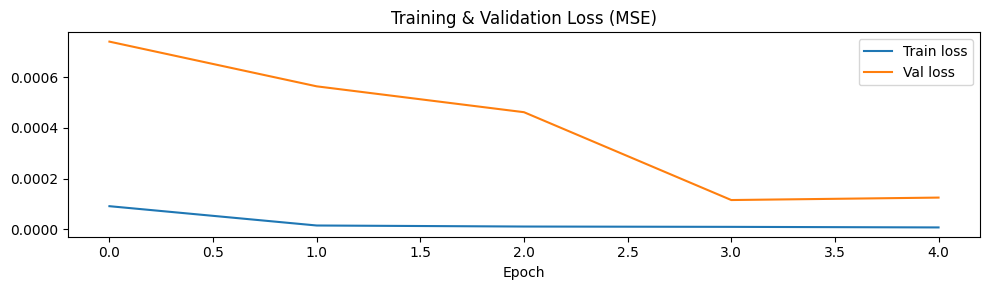

In [82]:

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


plt.figure(figsize=(10, 3))
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Training & Validation Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

In [83]:

y_pred_scaled = model.predict(X_test).flatten()

y_pred = scaler_close.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_close.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'MAE  : ${mae:.2f}')
print(f'RMSE : ${rmse:.2f}')
print(f'MAPE : {mape:.2f}%')

62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step
MAE  : $20.05
RMSE : $27.47
MAPE : 12.52%


In [84]:
last_sequence = features[-LOOKBACK:].reshape(1, LOOKBACK, features.shape[1])
next_scaled   = model.predict(last_sequence)[0, 0]
next_price    = scaler_close.inverse_transform([[next_scaled]])[0, 0]

last_close = data['Close'].iloc[-1]
direction  = '↑' if next_price > last_close else '↓'
print(f'Last close : ${last_close:.2f}')
print(f'Predicted  : ${next_price:.2f}  {direction}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Last close : $240.91
Predicted  : $191.78  ▼


In [85]:
data.head()
print(data.columns.tolist())


['Close', 'Log_Volume', 'Close_scaled', 'LogVol_scaled']


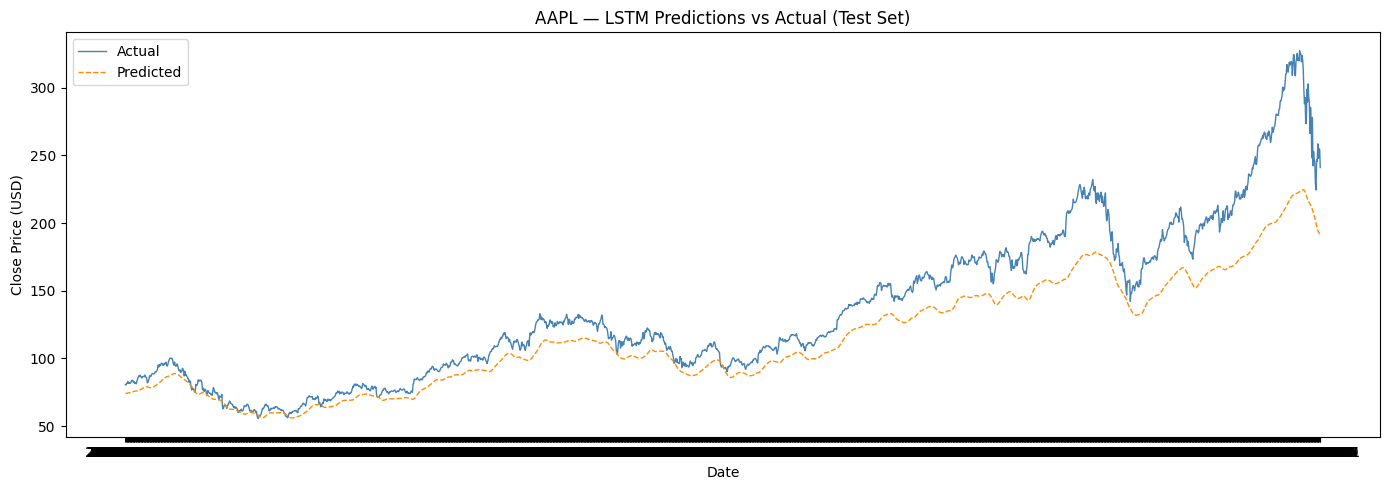

In [86]:
df = pd.read_csv(f"{path}/stocks/AAPL.csv")
test_dates = df['Date'].iloc[split + LOOKBACK:].values

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_true, label='Actual',    color='steelblue',  linewidth=1)
plt.plot(test_dates, y_pred, label='Predicted', color='darkorange', linewidth=1, linestyle='--')
plt.title('AAPL — LSTM Predictions vs Actual (Test Set)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [87]:
data = pd.read_csv(f"{path}/stocks/AAPL.csv")

In [88]:
data = df[['Close', 'Volume']].copy()
data['Log_Volume'] = np.log1p(data['Volume'])
data.drop(columns=['Volume'], inplace=True)


scaler_close  = MinMaxScaler()
scaler_logvol = MinMaxScaler()

data['Close_scaled']  = scaler_close.fit_transform(data[['Close']])
data['LogVol_scaled'] = scaler_logvol.fit_transform(data[['Log_Volume']])

features = data[['Close_scaled', 'LogVol_scaled']].values
target   = data['Close_scaled'].values
print('Feature matrix:', features.shape)

Feature matrix: (9909, 2)


In [89]:
LOOKBACK = 60

X, y = [], []
for i in range(LOOKBACK, len(features)):
    X.append(features[i - LOOKBACK : i])
    y.append(target[i])

X, y = np.array(X), np.array(y)


split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (7879, 60, 2)  |  Test: (1970, 60, 2)


In [90]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model1 = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(LOOKBACK, X.shape[2])),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model1.compile(optimizer='adam', loss='mse')
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 58, 64)         │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 27, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1664)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       106,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,777 (514.75 KB)

 Trainable params: 131,777 (514.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 6.8846e-04 - val_loss: 0.0053
Epoch 2/5
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 3.9965e-05 - val_loss: 0.0062
Epoch 3/5
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 4.0625e-05 - val_loss: 0.0073
Epoch 4/5
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 3.1463e-05 - val_loss: 0.0077
Epoch 5/5
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 2.9006e-05 - val_loss: 0.0063


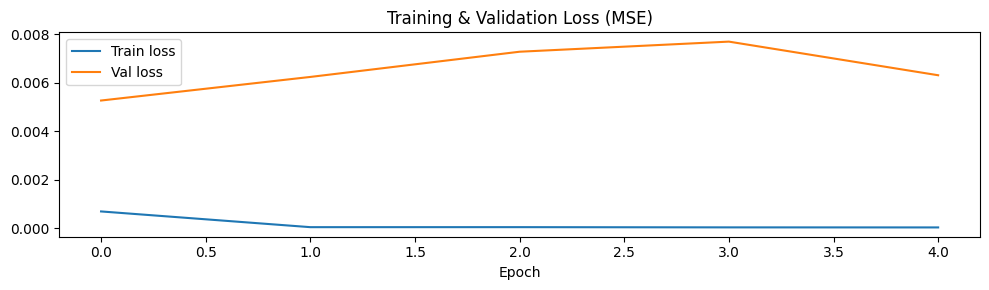

In [91]:

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model1.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


plt.figure(figsize=(10, 3))
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Training & Validation Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

In [92]:

y_pred_scaled = model1.predict(X_test).flatten()

y_pred = scaler_close.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_close.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'MAE  : ${mae:.2f}')
print(f'RMSE : ${rmse:.2f}')
print(f'MAPE : {mape:.2f}%')

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MAE  : $83.13
RMSE : $92.65
MAPE : 60.05%


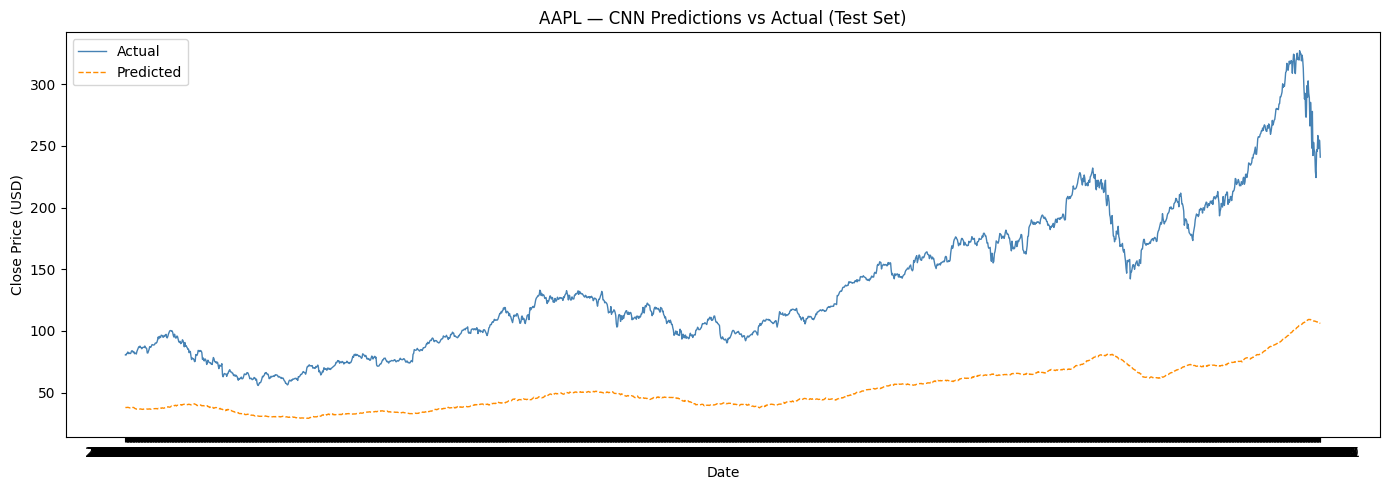

In [93]:
df = pd.read_csv(f"{path}/stocks/AAPL.csv")
test_dates = df['Date'].iloc[split + LOOKBACK:].values

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_true, label='Actual',    color='steelblue',  linewidth=1)
plt.plot(test_dates, y_pred, label='Predicted', color='darkorange', linewidth=1, linestyle='--')
plt.title('AAPL — CNN Predictions vs Actual (Test Set)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [94]:
last_sequence = features[-LOOKBACK:].reshape(1, LOOKBACK, features.shape[1])
next_scaled   = model1.predict(last_sequence)[0, 0]
next_price    = scaler_close.inverse_transform([[next_scaled]])[0, 0]

last_close = df['Close'].iloc[-1]
direction  = '↑' if next_price > last_close else '↓'
print(f'Last close : ${last_close:.2f}')
print(f'Predicted  : ${next_price:.2f}  {direction}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Last close : $240.91
Predicted  : $105.76  ▼


In [95]:
data = pd.read_csv(f"{path}/stocks/AAPL.csv")

In [96]:
data = data[['Close', 'Volume']].copy()
data['Log_Volume'] = np.log1p(data['Volume'])
data.drop(columns=['Volume'], inplace=True)

scaler_close  = MinMaxScaler()
scaler_logvol = MinMaxScaler()

data['Close_scaled']  = scaler_close.fit_transform(data[['Close']])
data['LogVol_scaled'] = scaler_logvol.fit_transform(data[['Log_Volume']])

features = data[['Close_scaled', 'LogVol_scaled']].values
target   = data['Close_scaled'].values
print('Feature matrix:', features.shape)

Feature matrix: (9909, 2)


In [97]:
LOOKBACK = 60

X, y = [], []
for i in range(LOOKBACK, len(features)):
    X.append(features[i - LOOKBACK : i])
    y.append(target[i])

X, y = np.array(X), np.array(y)


split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (7879, 60, 2)  |  Test: (1970, 60, 2)


A simple RNN passes a single hidden state from one time step to the next which makes it faster and simpler, but no distant history. 128 units means layer produces 128 numbers as its hidden state each time step. Second layer compresses down to 64 which forces network to summarize what it learned into a smaller representation.

In [98]:
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

model2 = Sequential([

    SimpleRNN(128, activation='tanh', return_sequences=True,
              input_shape=(LOOKBACK, X.shape[2])),
    Dropout(0.2),


    SimpleRNN(64, activation='tanh', return_sequences=False),
    Dropout(0.2),


    Dense(32, activation='relu'),
    Dense(1)
])

model2.compile(optimizer='adam', loss='mse')
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 60, 128)        │        16,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,233 (122.00 KB)

 Trainable params: 31,233 (122.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
222/222 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - loss: 0.0146 - val_loss: 0.0186
Epoch 2/5
222/222 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - loss: 4.9706e-04 - val_loss: 0.0183
Epoch 3/5
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 3.3673e-04 - val_loss: 0.0185
Epoch 4/5
222/222 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 3.0351e-04 - val_loss: 0.0183
Epoch 5/5
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - loss: 2.8427e-04 - val_loss: 0.0184


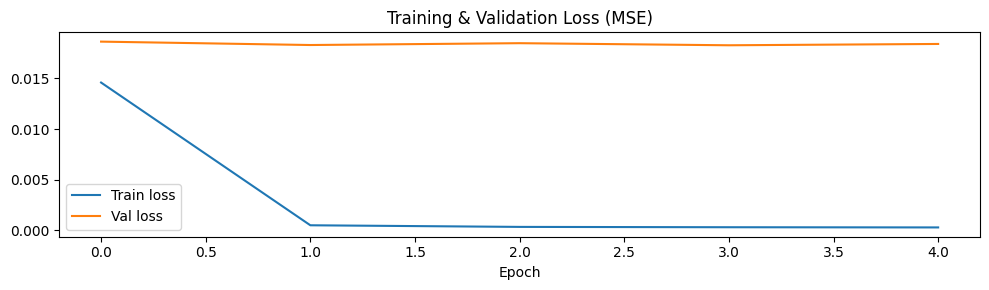

In [99]:

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model2.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


plt.figure(figsize=(10, 3))
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Training & Validation Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

In [100]:
y_pred_scaled = model2.predict(X_test).flatten()

y_pred = scaler_close.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_close.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'MAE  : ${mae:.2f}')
print(f'RMSE : ${rmse:.2f}')
print(f'MAPE : {mape:.2f}%')

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
MAE  : $163.33
RMSE : $191.63
MAPE : 112.98%


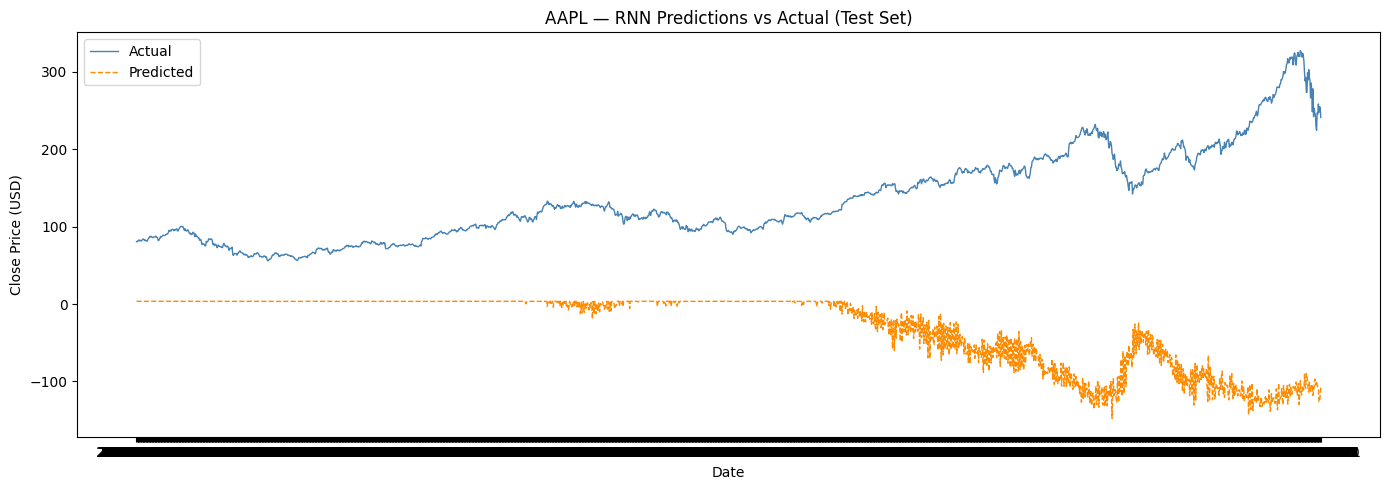

In [101]:
test_dates = df['Date'].iloc[split + LOOKBACK:].values

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_true, label='Actual',    color='steelblue',  linewidth=1)
plt.plot(test_dates, y_pred, label='Predicted', color='darkorange', linewidth=1, linestyle='--')
plt.title('AAPL — RNN Predictions vs Actual (Test Set)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [117]:
last_sequence = features[-LOOKBACK:].reshape(1, LOOKBACK, features.shape[1])
next_scaled   = model2.predict(last_sequence)[0, 0]
next_price    = scaler_close.inverse_transform([[next_scaled]])[0, 0]

last_close = df['Close'].iloc[-1]
direction  = '↑' if next_price > last_close else '↓'
print(f'Last close : ${last_close:.2f}')
print(f'Predicted  : ${next_price:.2f}  {direction}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
Last close : $240.91
Predicted  : $-108.75  ↓


ARIMA

In [106]:
data = pd.read_csv(f"{path}/stocks/AAPL.csv")

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
!pip install pmdarima --quiet

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

close = data['Close'].values

result = adfuller(close)
print(f'ADF Statistic : {result[0]:.4f}')
print(f'p-value       : {result[1]:.4f}')
print()
if result[1] > 0.05:
    print('Series is NON-STATIONARY — differencing is needed (d >= 1)')
else:
    print('Series is STATIONARY — no differencing needed (d = 0)')

ADF Statistic : 1.8940
p-value       : 0.9985

Series is NON-STATIONARY — differencing is needed (d >= 1)


ADF Statistic (differenced) : -15.3553
p-value       (differenced) : 0.0000

Differenced series is stationary, use d=1


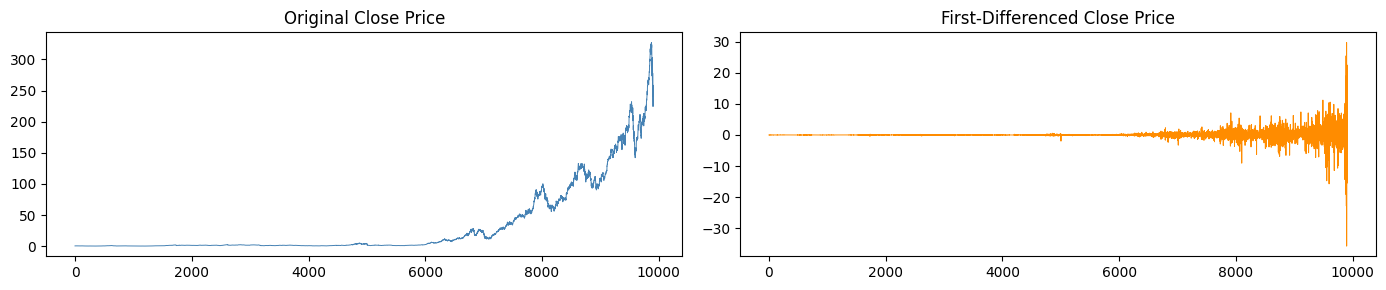

In [108]:
close_diff = pd.Series(close).diff().dropna().values

result_diff = adfuller(close_diff)
print(f'ADF Statistic (differenced) : {result_diff[0]:.4f}')
print(f'p-value       (differenced) : {result_diff[1]:.4f}')
print()
if result_diff[1] < 0.05:
    print('Differenced series is stationary, use d=1')

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].plot(close, linewidth=0.7, color='steelblue')
axes[0].set_title('Original Close Price')
axes[1].plot(close_diff, linewidth=0.7, color='darkorange')
axes[1].set_title('First-Differenced Close Price')
plt.tight_layout()
plt.show()

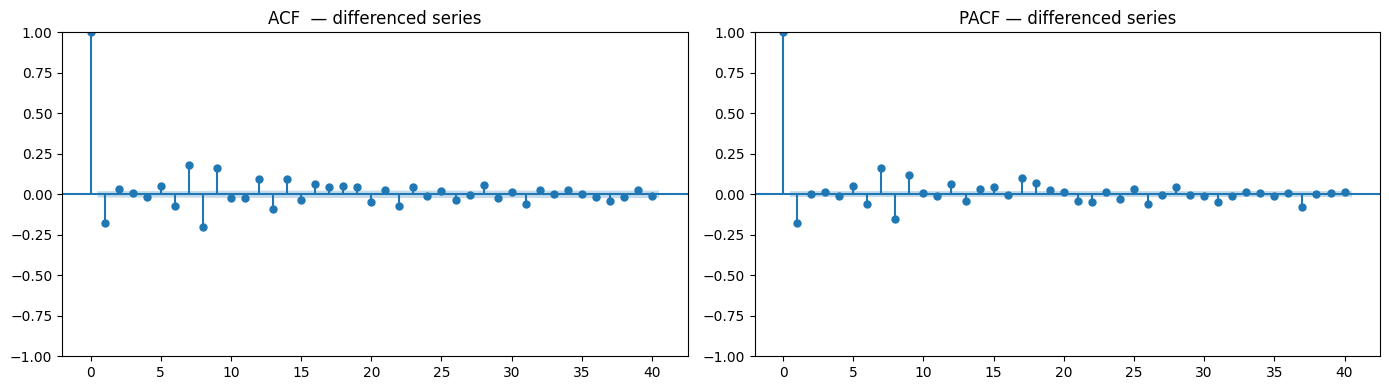

In [109]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf (close_diff, lags=40, ax=axes[0], title='ACF  — differenced series')
plot_pacf(close_diff, lags=40, ax=axes[1], title='PACF — differenced series')
plt.tight_layout()
plt.show()

In [110]:
print('Searching for best ARIMA order')
auto_model = auto_arima(
    close,
    d=1,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore'
)

best_order = auto_model.order
print(f'\nBest order found: ARIMA{best_order}')
print(auto_model.summary())

Searching for best ARIMA order

Best order found: ARIMA(5, 1, 1)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 9909
Model:               SARIMAX(5, 1, 1)   Log Likelihood              -16605.507
Date:                Sun, 26 Apr 2026   AIC                          33227.015
Time:                        21:26:28   BIC                          33284.624
Sample:                             0   HQIC                         33246.524
                               - 9909                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0477      0.027      1.771      0.077      -0.005       0.100
ar.L1         -0.9580      0.004   -221.422      0.000      -0.966

In [111]:
split = int(len(close) * 0.80)
train, test = close[:split], close[split:]
print(f'Train: {len(train):,} days  |  Test: {len(test):,} days')

Train: 7,927 days  |  Test: 1,982 days


In [112]:

history     = list(train)
predictions = []
p, d, q     = best_order

fit = ARIMA(history, order=(p, d, q)).fit()

print(f'Running rolling forecast over {len(test):,} test days')
for i, actual in enumerate(test):
    yhat = fit.forecast(steps=1)[0]
    predictions.append(yhat)
    fit = fit.append([actual], refit=False)
    if (i + 1) % 100 == 0:
        print(f'  {i + 1}/{len(test)} done')

predictions = np.array(predictions)
print('Rolling forecast complete')

Running rolling forecast over 1,982 test days
  100/1982 done
  200/1982 done
  300/1982 done
  400/1982 done
  500/1982 done
  600/1982 done
  700/1982 done
  800/1982 done
  900/1982 done
  1000/1982 done
  1100/1982 done
  1200/1982 done
  1300/1982 done
  1400/1982 done
  1500/1982 done
  1600/1982 done
  1700/1982 done
  1800/1982 done
  1900/1982 done
Rolling forecast complete


In [113]:
y_true = test
y_pred = predictions

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'MAE  : ${mae:.2f}')
print(f'RMSE : ${rmse:.2f}')
print(f'MAPE : {mape:.2f}%')

MAE  : $1.65
RMSE : $2.94
MAPE : 1.19%


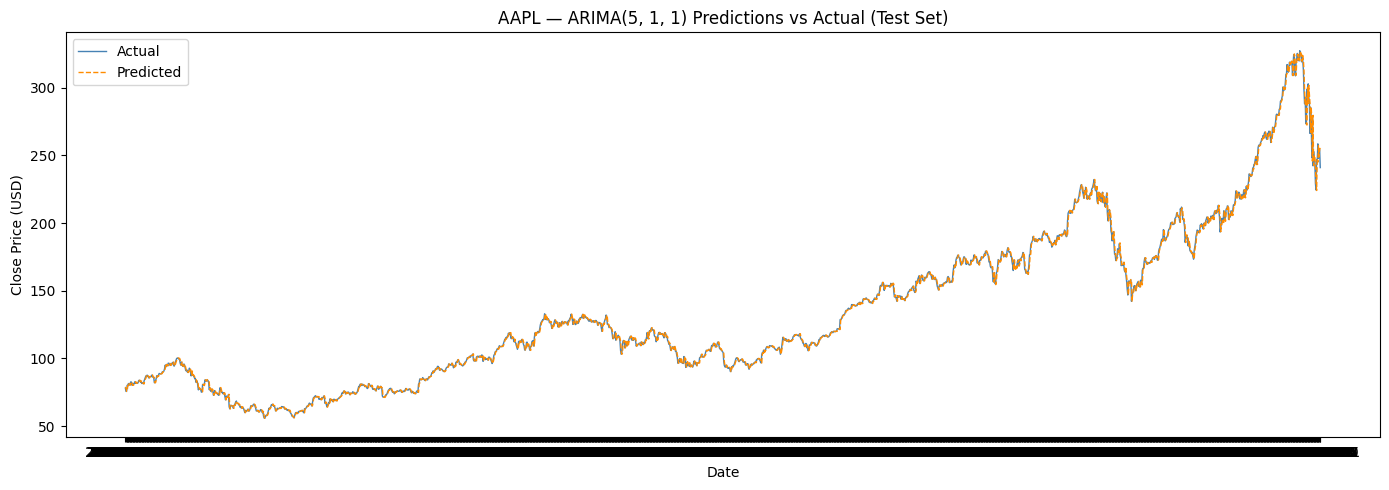

In [114]:
test_dates = df['Date'].iloc[split:].values

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_true, label='Actual',    color='steelblue',  linewidth=1)
plt.plot(test_dates, y_pred, label='Predicted', color='darkorange', linewidth=1, linestyle='--')
plt.title(f'AAPL — ARIMA{best_order} Predictions vs Actual (Test Set)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [115]:
final_model = ARIMA(close, order=best_order).fit()
next_price  = final_model.forecast(steps=1)[0]

last_close = close[-1]
direction  = '↑' if next_price > last_close else '↓'
print(f'Last close : ${last_close:.2f}')
print(f'Predicted  : ${next_price:.2f}  {direction}')

Last close : $240.91
Predicted  : $244.48  ↑
